# Pandas

Pandas is a library for storing and manipulating tabular data, or data stored in rows and columns like a spreadsheet. Pandas is a huge library with many different functions and methods, so what follows is a brief introduction to the most important functions for data management.

::: {.callout-note}
If you encounter any part of Pandas out in the wild that you don't see here, you can always refer to the [Pandas documentation](https://pandas.pydata.org/docs/user_guide/index.html#user-guide).
:::

## DataFrames and Series

Instead of normal Python lists and dictionaries, Pandas stores data in its own specialized objects. The main one is a *DataFrame*, which is a lot like a spreadsheet with rows and columns.

You can create a DataFrame directly with the `DataFrame()` class in Pandas, but it's more likely that you'll read in a DataFrame from a CSV or spreadsheet file. First you must import the library, and it's a good idea to import the `numpy` and `matplotlib` libraries as well.

::: {.callout-tip}
Numpy is a Python library for efficiently handling arrays and matrices of numbers. Matplotlib is a Python library for creating data visualizations. Pandas uses both under the hood to run background operations. You usually won't need to use them directly, but it's good to have them imported to avoid any mysterious errors.
:::

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Now you can use the `read_csv()` function to read in a comma-separated value (CSV) spreadsheet file. You must put the name of this file in quotes, and the file should be in the same directory as your Jupyter notebook (or else you should include a full path). The `read_csv()` function will also accept a URL that points to a CSV file online.

For this example, we'll use the file `mpg.csv` which comes from R's [ggplot2 library](https://www.rdocumentation.org/packages/ggplot2/versions/3.4.1/topics/mpg).

In [2]:
mpg = pd.read_csv("../data/mpg.csv")
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


::: {.callout-warning}
Jupyter nicely formats DataFrames as tables when you type the name of a variable containing a DataFrame. But if you use the `print()` function, it won't display as well.
:::

You can get basic information about your DataFrames columns using the `.info()` method.

In [3]:
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    str    
 1   model         234 non-null    str    
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    str    
 6   drv           234 non-null    str    
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    str    
 10  class         234 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 27.9 KB


A *Series* is a lot like a Python list, and each column of a DataFrame is a Series. You can access the columns of a Dataframe with dot notation.

In [4]:
mpg.model

0          a4
1          a4
2          a4
3          a4
4          a4
        ...  
229    passat
230    passat
231    passat
232    passat
233    passat
Name: model, Length: 234, dtype: str

You can also turn a list into a Series with the `Series()` class.

In [5]:
myseries = pd.Series([5, 6, 7, 8])
myseries

0    5
1    6
2    7
3    8
dtype: int64

## Selecting Rows and Columns

Once you have a DataFrame, you'll typically want to filter and select different rows or columns.

To filter specific rows, Pandas uses a bracket notation. It takes conditional statements that are similar to [Python conditions](/python.html#conditions).

In [6]:
# Get cars with fewer than 6 cylinders
four_cylinders = mpg[mpg.cyl < 6]
four_cylinders

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
7,audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
226,volkswagen,new beetle,2.5,2008,5,auto(s6),f,20,29,r,subcompact
227,volkswagen,passat,1.8,1999,4,manual(m5),f,21,29,p,midsize
228,volkswagen,passat,1.8,1999,4,auto(l5),f,18,29,p,midsize
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize


You can also use the operators `&` (and), `|` (or), and `!` (not) to combine conditional filters.

In [7]:
# Get Volkswagens and Fords
vw_ford = mpg[(mpg.manufacturer == 'volkswagen') | (mpg.manufacturer == 'ford')]
vw_ford

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
74,ford,expedition 2wd,4.6,1999,8,auto(l4),r,11,17,r,suv
75,ford,expedition 2wd,5.4,1999,8,auto(l4),r,11,17,r,suv
76,ford,expedition 2wd,5.4,2008,8,auto(l6),r,12,18,r,suv
77,ford,explorer 4wd,4.0,1999,6,auto(l5),4,14,17,r,suv
78,ford,explorer 4wd,4.0,1999,6,manual(m5),4,15,19,r,suv
79,ford,explorer 4wd,4.0,1999,6,auto(l5),4,14,17,r,suv
80,ford,explorer 4wd,4.0,2008,6,auto(l5),4,13,19,r,suv
81,ford,explorer 4wd,4.6,2008,8,auto(l6),4,13,19,r,suv
82,ford,explorer 4wd,5.0,1999,8,auto(l4),4,13,17,r,suv
83,ford,f150 pickup 4wd,4.2,1999,6,auto(l4),4,14,17,r,pickup


You can use a double bracket notation to select a subset of columns.

::: {.callout-tip}
Using single brackets or dot notation will get you a single column as a Series.
:::

In [8]:
class_cty_hwy = mpg[["class", "cty", "hwy"]]
class_cty_hwy

,class,cty,hwy
0,compact,18,29
1,compact,21,29
2,compact,20,31
3,compact,21,30
4,compact,16,26
...,...,...,...
229,midsize,19,28
230,midsize,21,29
231,midsize,16,26
232,midsize,18,26


## Data Wrangling

In addtion to selecting rows and columns from DataFrames, you can also use Pandas to do a wide variety of data transformations.

### Sorting

In [9]:
mpg.sort_values("year", ascending=False)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
117,hyundai,tiburon,2.0,2008,4,manual(m5),f,20,28,r,subcompact
120,hyundai,tiburon,2.7,2008,6,manual(m6),f,16,24,r,subcompact
122,jeep,grand cherokee 4wd,3.0,2008,6,auto(l5),4,17,22,d,suv
123,jeep,grand cherokee 4wd,3.7,2008,6,auto(l5),4,15,19,r,suv
126,jeep,grand cherokee 4wd,4.7,2008,8,auto(l5),4,9,12,e,suv
...,...,...,...,...,...,...,...,...,...,...,...
130,land rover,range rover,4.0,1999,8,auto(l4),4,11,15,p,suv
50,dodge,dakota pickup 4wd,3.9,1999,6,auto(l4),4,13,17,r,pickup
51,dodge,dakota pickup 4wd,3.9,1999,6,manual(m5),4,14,17,r,pickup
125,jeep,grand cherokee 4wd,4.7,1999,8,auto(l4),4,14,17,r,suv


### Counting

In [10]:
mpg.value_counts("manufacturer")

manufacturer
dodge         37
toyota        34
volkswagen    27
ford          25
chevrolet     19
audi          18
hyundai       14
subaru        14
nissan        13
honda          9
jeep           8
pontiac        5
land rover     4
mercury        4
lincoln        3
Name: count, dtype: int64

### Renaming Columns

In [11]:
# Note the use of a Python dictionary as this method's argument
mpg = mpg.rename({"cty":"city", "hwy": "highway"})
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


### Create new columns

You can use `assign()` to create new columns based on existing ones.

In [12]:
mpg = mpg.assign(displ_per_cyl = mpg.displ/mpg.cyl)
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,0.450000
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,0.450000
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,0.500000
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,0.500000
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,0.466667
...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,0.500000
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,0.500000
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,0.466667
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,0.466667


### Grouping and Summarizing

This combines a couple functions that exist within Pandas to create *summary tables*.

Pandas has a wide range of summary statistics that you can apply to individual columns.

In [13]:
# Average city fuel efficiency
mpg.cty.mean()

np.float64(16.858974358974358)

In [14]:
# Standard deviation of highway fuel efficiency
mpg.hwy.std()

np.float64(5.9546434411664455)

Pandas also has a `.groupby()` method (which returns a generator) that groups categorical variables.

In [15]:
mpg.groupby("manufacturer")

By itself, `.groupby()` doesn't show anything. It needs to be combined with a summary statistic to create a summary table.

In [16]:
# Averages by manufacturer
# set `numeric_only=True` to avoid a warning
mpg.groupby("manufacturer").mean(numeric_only=True)

,displ,year,cyl,cty,hwy,displ_per_cyl
manufacturer,,,,,,
audi,2.544444,2003.500000,5.222222,17.611111,26.444444,0.484722
chevrolet,5.063158,2004.684211,7.263158,15.000000,21.894737,0.686842
dodge,4.378378,2004.108108,7.081081,13.135135,17.945946,0.616216
ford,4.536000,2002.600000,7.200000,14.000000,19.360000,0.633667
honda,1.711111,2003.000000,4.000000,24.444444,32.555556,0.427778
hyundai,2.428571,2004.142857,4.857143,18.642857,26.857143,0.509524
jeep,4.575000,2005.750000,7.250000,13.500000,17.625000,0.627604
land rover,4.300000,2003.500000,8.000000,11.500000,16.500000,0.537500
lincoln,5.400000,2002.000000,8.000000,11.333333,17.000000,0.675000


### Dropping Null Values

For many statistical modeling tasks, you need to drop rows that contain null values. Pandas lets you do this easily with `.dropna()`.

::: {.callout-note}
Pandas typically stores null values as NaN, which stands for "not a number."
:::

In [17]:
# Drop any row that contains a null value in any column
mpg = mpg.dropna()
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,0.450000
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,0.450000
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,0.500000
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,0.500000
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,0.466667
...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,0.500000
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,0.500000
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,0.466667
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,0.466667


::: {.callout-warning}
The `mpg` dataset doesn't contain any null values, so right now this code isn't accomplishing anything. But it will work when null values are present!
:::

You can also drop null values from only a subset of columns.

In [18]:
# Drop any rows that contain null values in a subset of columns
mpg = mpg.dropna(subset=["model", "displ"])
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,0.450000
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,0.450000
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,0.500000
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,0.500000
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,0.466667
...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,0.500000
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,0.500000
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,0.466667
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,0.466667


## Sampling

Many statistical methods, especially hypothesis tests, require you to take a random sample of your overall data. Again, Pandas provides an easy way to do this with the `.sample()` method.

You can take a sample of rows from an entire dataframe.

In [19]:
# Get 5 random rows from mpg
mpg.sample(5)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl
219,volkswagen,jetta,2.8,1999,6,auto(l4),f,16,23,r,compact,0.466667
175,toyota,4runner 4wd,3.4,1999,6,auto(l4),4,15,19,r,suv,0.566667
63,dodge,durango 4wd,5.9,1999,8,auto(l4),4,11,15,r,suv,0.737500
220,volkswagen,jetta,2.8,1999,6,manual(m5),f,17,24,r,compact,0.466667
130,land rover,range rover,4.0,1999,8,auto(l4),4,11,15,p,suv,0.500000


You can also get a sample of a specific column.

In [20]:
# Get 5 sample engine displacement values, as a series
mpg.displ.sample(5)

172    2.5
61     5.2
178    4.7
35     3.5
128    5.7
Name: displ, dtype: float64

You can also sample with replacement. (This is also called "bootstrap sampling.") This makes it possible to have the same value in your sample twice.

In [21]:
mpg.displ.sample(5, replace=True)

29     5.3
162    2.5
204    3.4
80     4.0
225    2.5
Name: displ, dtype: float64

Pandas will also let you get a fraction of values instead of a set number in your sample.

In [22]:
# Get a random sample of one twentieth the size of the dataset
mpg.sample(frac=.05)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl
119,hyundai,tiburon,2.7,2008,6,auto(l4),f,17,24,r,subcompact,0.450000
128,jeep,grand cherokee 4wd,5.7,2008,8,auto(l5),4,13,18,r,suv,0.712500
160,subaru,forester awd,2.5,1999,4,auto(l4),4,18,24,r,suv,0.625000
157,pontiac,grand prix,3.8,2008,6,auto(l4),f,18,28,r,midsize,0.633333
69,dodge,ram 1500 pickup 4wd,4.7,2008,8,manual(m6),4,9,12,e,pickup,0.587500
10,audi,a4 quattro,2.0,2008,4,auto(s6),4,19,27,p,compact,0.500000
78,ford,explorer 4wd,4.0,1999,6,manual(m5),4,15,19,r,suv,0.666667
197,toyota,corolla,1.8,2008,4,auto(l4),f,26,35,r,compact,0.450000
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,0.500000
40,dodge,caravan 2wd,3.3,1999,6,auto(l4),f,16,22,r,minivan,0.550000


There's one more trick you can do with sampling. Sometimes you don't need to get a smaller random sample: instead, you just want to reshuffle every row of the dataset. You can do this by setting `frac` to 1. In a way, you're taking a random sample that is 100% of the size of the dataset! (But make sure you do this *without* replacement.)

In [23]:
mpg.displ.sample(frac=1)

63     5.9
11     2.8
126    4.7
168    2.5
163    2.5
      ... 
35     3.5
111    2.4
95     4.6
195    1.8
8      1.8
Name: displ, Length: 234, dtype: float64

Pandas will remember the indices in your new Series, which means if you use this reordered sample it might put things back in order for you! To avoid this, you can reset the index and drop the old labels.

In [24]:
mpg.displ.sample(frac=1).reset_index(drop=True)

0      3.0
1      1.9
2      2.8
3      3.7
4      3.6
      ... 
229    4.6
230    4.0
231    2.7
232    3.7
233    3.1
Name: displ, Length: 234, dtype: float64

## Combining Datasets

### Stack Data with Concatenation

If you have two datasets with identical columns but different rows, you can combine or "stack" the two datasets into one.

In [25]:
# Let's imagine we have two datasets.
# One for manual transmission cars:

manual = pd.read_csv("../data/manual.csv")
manual

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
1,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
2,audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact
3,audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
4,audi,a4 quattro,2.0,2008,4,manual(m6),4,20,28,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
72,volkswagen,new beetle,2.0,1999,4,manual(m5),f,21,29,r,subcompact
73,volkswagen,new beetle,2.5,2008,5,manual(m5),f,20,28,r,subcompact
74,volkswagen,passat,1.8,1999,4,manual(m5),f,21,29,p,midsize
75,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize


In [26]:
# And one for automatic transmissions:
automatic = pd.read_csv("../data/automatic.csv")
automatic

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
2,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
3,audi,a4,3.1,2008,6,auto(av),f,18,27,p,compact
4,audi,a4 quattro,1.8,1999,4,auto(l5),4,16,25,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
152,volkswagen,new beetle,2.5,2008,5,auto(s6),f,20,29,r,subcompact
153,volkswagen,passat,1.8,1999,4,auto(l5),f,18,29,p,midsize
154,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
155,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize


In [27]:
# You can combine these into one with pd.concat()

mpg_concat = pd.concat([manual, automatic])
mpg_concat

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
1,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
2,audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact
3,audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
4,audi,a4 quattro,2.0,2008,4,manual(m6),4,20,28,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
152,volkswagen,new beetle,2.5,2008,5,auto(s6),f,20,29,r,subcompact
153,volkswagen,passat,1.8,1999,4,auto(l5),f,18,29,p,midsize
154,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
155,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize


### Switch Rows and Columns with Pivot and Melt

Sometimes your data isn't tidy, and rows should be columns while columns should be rows. You can resolve these problems using Pandas' "pivot" and "melt" concepts—this is similar to Pivot Tables in Excel.

In [28]:
# Let's imagine you have a dataset with column headings in the rows

long_mpg = pd.read_csv("../data/melted_mpg.csv")
long_mpg

,manufacturer,model,year,trans,variable,value
0,audi,a4,1999,auto(l5),displ,1.8
1,audi,a4,1999,manual(m5),displ,1.8
2,audi,a4,2008,manual(m6),displ,2.0
3,audi,a4,2008,auto(av),displ,2.0
4,audi,a4 quattro,1999,manual(m5),displ,1.8
...,...,...,...,...,...,...
968,volkswagen,new beetle,2008,auto(s6),class,subcompact
969,volkswagen,passat,1999,manual(m5),class,midsize
970,volkswagen,passat,1999,auto(l5),class,midsize
971,volkswagen,passat,2008,auto(s6),class,midsize


In [29]:
# Use pivot to turn the "variable" column into the column names
# You must specify which columns you want to retain as indices
# Make sure you add .reset_index()

pivoted_mpg = long_mpg.pivot(index=["manufacturer", "model", "year", "trans"], columns="variable", values="value").reset_index()
pivoted_mpg

variable,manufacturer,model,year,trans,class,cty,cyl,displ,drv,fl,hwy
0,audi,a4,1999,auto(l5),compact,18,4,1.8,f,p,29
1,audi,a4,1999,manual(m5),compact,21,4,1.8,f,p,29
2,audi,a4,2008,auto(av),compact,21,4,2.0,f,p,30
3,audi,a4,2008,manual(m6),compact,20,4,2.0,f,p,31
4,audi,a4 quattro,1999,auto(l5),compact,16,4,1.8,4,p,25
...,...,...,...,...,...,...,...,...,...,...,...
134,volkswagen,new beetle,2008,manual(m5),subcompact,20,5,2.5,f,r,28
135,volkswagen,passat,1999,auto(l5),midsize,18,4,1.8,f,p,29
136,volkswagen,passat,1999,manual(m5),midsize,21,4,1.8,f,p,29
137,volkswagen,passat,2008,auto(s6),midsize,19,4,2.0,f,p,28


In [30]:
# You can use .melt() to go in the opposite direction
# Again you must specify the columns you want to keep as indices

melted_mpg = pivoted_mpg.melt(id_vars = ["manufacturer", "model", "year", "trans"])
melted_mpg

,manufacturer,model,year,trans,variable,value
0,audi,a4,1999,auto(l5),class,compact
1,audi,a4,1999,manual(m5),class,compact
2,audi,a4,2008,auto(av),class,compact
3,audi,a4,2008,manual(m6),class,compact
4,audi,a4 quattro,1999,auto(l5),class,compact
...,...,...,...,...,...,...
968,volkswagen,new beetle,2008,manual(m5),hwy,28
969,volkswagen,passat,1999,auto(l5),hwy,29
970,volkswagen,passat,1999,manual(m5),hwy,29
971,volkswagen,passat,2008,auto(s6),hwy,28


### Join Datasets with Merge

If your columns or rows don't match exactly, you can't use `pd.concat()`. But you can still combine datasets with a database-style JOIN (just like in SQL!) using the `pd.merge()` function.

::: {.callout-warning}
This database-style combining of tables is really powerful, and it can get more complicated than what we have time to cover in this class. I recommend checking out [McKinney Ch. 8.2](https://wesmckinney.com/book/data-wrangling#prep_merge_join) for more details, and this all is covered in much more detail in CIS 112!
:::

In [31]:
# Let's assume you have a dataset without the vehicle class column

missing_mpg = pd.read_csv("../data/mpg_no_class.csv")
missing_mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p
...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p


In [32]:
# And you also have a dataset (with fewer rows) that has
# class info for each make and year of vehicle

class_mpg = pd.read_csv("../data/mpg_class.csv")
class_mpg

,manufacturer,model,year,class
0,audi,a4,1999,compact
1,audi,a4,2008,compact
2,audi,a4 quattro,1999,compact
3,audi,a4 quattro,2008,compact
4,audi,a6 quattro,1999,midsize
...,...,...,...,...
71,volkswagen,jetta,2008,compact
72,volkswagen,new beetle,1999,subcompact
73,volkswagen,new beetle,2008,subcompact
74,volkswagen,passat,1999,midsize


In [33]:
# You can add the class column to your dataframe using merge

merged_mpg = pd.merge(missing_mpg, class_mpg, how="left", on=["manufacturer", "model", "year"])
merged_mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


::: {.callout-note}
Wes McKinney's excellent book *Python for Data Analysis* has lots more examples and many additional function. In particular, you can check out [Chapter 5](https://wesmckinney.com/book/pandas-basics.html#pandas_frame) and [Chapter 8](https://wesmckinney.com/book/data-wrangling.html).
:::

## Data Types

Python and Pandas accommodate many different types of data, and Pandas in particular deals with a range of data types beyond what we've already discussed. Usually, you're likely encounter: numerical data (integers and floats), categorical data (categories and objects), text data (objects and strings), time data (dates and times), and location data (geocoordinates).

::: {.callout-caution}
Remember, the data types that programming languages use are not always exactly equivalent to the general data types that data scientists might recognize! You're always trying to use a technical data type that's the best match for the data you're trying to store.
:::

### Changing Data Types

A good way to check what data types are in your data is the `.info()` method.

In [34]:
mpg.info()

<class 'pandas.DataFrame'>
Index: 234 entries, 0 to 233
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   manufacturer   234 non-null    str    
 1   model          234 non-null    str    
 2   displ          234 non-null    float64
 3   year           234 non-null    int64  
 4   cyl            234 non-null    int64  
 5   trans          234 non-null    str    
 6   drv            234 non-null    str    
 7   cty            234 non-null    int64  
 8   hwy            234 non-null    int64  
 9   fl             234 non-null    str    
 10  class          234 non-null    str    
 11  displ_per_cyl  234 non-null    float64
dtypes: float64(2), int64(4), str(6)
memory usage: 31.5 KB


Pandas tries its best to guess the correct data type when your data is being imported. It doesn't always get things right! For example, if there's any non-numeric character in a numeric column (like a dollar sign), it will identify that as an `object` rather than an `int` or `float`.

::: {.callout-tip}
Pandas will use `object` for any non-numeric data it doesn't know how to deal with. Usually, it's fine to leave this alone for categorical data, but sometimes you will need to use the more robust [Category data types](https://pandas.pydata.org/docs/user_guide/categorical.html#categorical-data) that Pandas provides. This lets you label categories and deal with any numeric (ordinal) data that's actually representing a category.
:::

If a data type is encoded incorrectly, there are two ways to change it:

In [35]:
# The first way is to use the general astype function:

mpg = mpg.assign(manufacturer = mpg.manufacturer.astype("category"))
mpg.info()

<class 'pandas.DataFrame'>
Index: 234 entries, 0 to 233
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   manufacturer   234 non-null    category
 1   model          234 non-null    str     
 2   displ          234 non-null    float64 
 3   year           234 non-null    int64   
 4   cyl            234 non-null    int64   
 5   trans          234 non-null    str     
 6   drv            234 non-null    str     
 7   cty            234 non-null    int64   
 8   hwy            234 non-null    int64   
 9   fl             234 non-null    str     
 10  class          234 non-null    str     
 11  displ_per_cyl  234 non-null    float64 
dtypes: category(1), float64(2), int64(4), str(5)
memory usage: 28.6 KB


In [36]:
# The second way is to use a function specific to
# convert something to a number, a date, or something else:

mpg = mpg.assign(hwy = pd.to_numeric(mpg.hwy, downcast="float"))
# The downcast='float' changes your data from an int to a float
# but you could also use this to go from an object to an int or float

mpg.info()

<class 'pandas.DataFrame'>
Index: 234 entries, 0 to 233
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   manufacturer   234 non-null    category
 1   model          234 non-null    str     
 2   displ          234 non-null    float64 
 3   year           234 non-null    int64   
 4   cyl            234 non-null    int64   
 5   trans          234 non-null    str     
 6   drv            234 non-null    str     
 7   cty            234 non-null    int64   
 8   hwy            234 non-null    float32 
 9   fl             234 non-null    str     
 10  class          234 non-null    str     
 11  displ_per_cyl  234 non-null    float64 
dtypes: category(1), float32(1), float64(2), int64(3), str(5)
memory usage: 27.7 KB


::: {.callout-important}
Converting data from one data type to another will sometimes *change the data itself*. Make sure to be aware of the changes you're making! For example, changing from a `float` to an `int` might round your data to the nearest whole number.
:::

### Dates and Times

The `datetime` data types in Python record years, months, days, hours, minutes, and seconds as distinct parts of a single cell of data. Pandas has [many different functions and methods](https://pandas.pydata.org/docs/user_guide/timeseries.html) for dealing with time data. A `datetime` is a special type of numeric data that is usually not automatically detected by Pandas.

In the `mpg` data, you can change the `year` column to a datetime:

In [37]:
# You must specify the format of the date or time in the existing data
# For example: "%m-%d-%Y" would be the format "05-30-2025"

mpg = mpg.assign(year = pd.to_datetime(mpg.year, format="%Y"))
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl
0,audi,a4,1.8,1999-01-01,4,auto(l5),f,18,29.0,p,compact,0.450000
1,audi,a4,1.8,1999-01-01,4,manual(m5),f,21,29.0,p,compact,0.450000
2,audi,a4,2.0,2008-01-01,4,manual(m6),f,20,31.0,p,compact,0.500000
3,audi,a4,2.0,2008-01-01,4,auto(av),f,21,30.0,p,compact,0.500000
4,audi,a4,2.8,1999-01-01,6,auto(l5),f,16,26.0,p,compact,0.466667
...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008-01-01,4,auto(s6),f,19,28.0,p,midsize,0.500000
230,volkswagen,passat,2.0,2008-01-01,4,manual(m6),f,21,29.0,p,midsize,0.500000
231,volkswagen,passat,2.8,1999-01-01,6,auto(l5),f,16,26.0,p,midsize,0.466667
232,volkswagen,passat,2.8,1999-01-01,6,manual(m5),f,18,26.0,p,midsize,0.466667


Now the year column is a formal `datetime`. Because we didn't have information on the day and month, it automatically assigned the dates to January 1st.

To access specific parts of a datetime object, you can use the `dt` namespace.

In [38]:
# Get just the year

mpg.year.dt.year

0      1999
1      1999
2      2008
3      2008
4      1999
       ... 
229    2008
230    2008
231    1999
232    1999
233    2008
Name: year, Length: 234, dtype: int32

In [39]:
# Get just the month

mpg.year.dt.month

0      1
1      1
2      1
3      1
4      1
      ..
229    1
230    1
231    1
232    1
233    1
Name: year, Length: 234, dtype: int32

::: {.callout-note}
Datetimes are commonly used to create time series graphs and analyze other changes over time (see the [Altair Guide](/guides/altair.ipynb) for more on this). When dealing with a machine learning model, you might need to convert a datetime back to a numeric value to get it to work properly. You can get information on these uses and many more in the [Pandas documentation](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-series-date-functionality).
:::

### Text Data and Strings

Text data is distinct from categorical data. Though nominal categories often exist in the form of text, there are lots of text data (names and IDs, longer descriptions, even whole novels!) that aren't categories.

Like with `datetime` data, Pandas lets you work with its string `objects` through a `str` namespace. This lets you manipulate strings (split them, concatenate them, replace them, and more) just like you would in Python.

::: {.callout-tip}
We'll only show a brief example here. The main place to find information about how to work with text in Pandas is on the [Text Data documentation page](https://pandas.pydata.org/docs/user_guide/text.html).
:::

In the `mpg` dataset, the `trans` (short for transmission) column includes two pieces of information. You can use the `str` namespace to separate this info into two columns.

First you can see what the split will look like:

In [40]:
# Split on the open paranthesis to get the two parts you need
mpg.trans.str.split("(")

0        [auto, l5)]
1      [manual, m5)]
2      [manual, m6)]
3        [auto, av)]
4        [auto, l5)]
           ...      
229      [auto, s6)]
230    [manual, m6)]
231      [auto, l5)]
232    [manual, m5)]
233      [auto, s6)]
Name: trans, Length: 234, dtype: object

Then you can get each part of the string and assign it to new columns. (You don't need to display the above part every time.)

In [41]:
# Note we can use assign to define columns for each part of the split
# Every time we manipulate a string
mpg = mpg.assign(
    trans = mpg.trans.str.split("(").str[0], 
    transmission_full = mpg.trans.str.split("(").str[1]
)
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl,transmission_full
0,audi,a4,1.8,1999-01-01,4,auto,f,18,29.0,p,compact,0.450000,l5)
1,audi,a4,1.8,1999-01-01,4,manual,f,21,29.0,p,compact,0.450000,m5)
2,audi,a4,2.0,2008-01-01,4,manual,f,20,31.0,p,compact,0.500000,m6)
3,audi,a4,2.0,2008-01-01,4,auto,f,21,30.0,p,compact,0.500000,av)
4,audi,a4,2.8,1999-01-01,6,auto,f,16,26.0,p,compact,0.466667,l5)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008-01-01,4,auto,f,19,28.0,p,midsize,0.500000,s6)
230,volkswagen,passat,2.0,2008-01-01,4,manual,f,21,29.0,p,midsize,0.500000,m6)
231,volkswagen,passat,2.8,1999-01-01,6,auto,f,16,26.0,p,midsize,0.466667,l5)
232,volkswagen,passat,2.8,1999-01-01,6,manual,f,18,26.0,p,midsize,0.466667,m5)


Then you can clean up the resulting new column using the `.strip()` method:

In [42]:
# The .strip() method removes text from the beginning or end of a string
# Use .replace() if you want to remove something from anywhere in a string
mpg = mpg.assign(transmission_full = mpg.transmission_full.str.strip(")"))
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class,displ_per_cyl,transmission_full
0,audi,a4,1.8,1999-01-01,4,auto,f,18,29.0,p,compact,0.450000,l5
1,audi,a4,1.8,1999-01-01,4,manual,f,21,29.0,p,compact,0.450000,m5
2,audi,a4,2.0,2008-01-01,4,manual,f,20,31.0,p,compact,0.500000,m6
3,audi,a4,2.0,2008-01-01,4,auto,f,21,30.0,p,compact,0.500000,av
4,audi,a4,2.8,1999-01-01,6,auto,f,16,26.0,p,compact,0.466667,l5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008-01-01,4,auto,f,19,28.0,p,midsize,0.500000,s6
230,volkswagen,passat,2.0,2008-01-01,4,manual,f,21,29.0,p,midsize,0.500000,m6
231,volkswagen,passat,2.8,1999-01-01,6,auto,f,16,26.0,p,midsize,0.466667,l5
232,volkswagen,passat,2.8,1999-01-01,6,manual,f,18,26.0,p,midsize,0.466667,m5


### Location Data

If your dataset has latitude and longitude values, or even specific place names, then you might be dealing with geospatial data. Geospatial data needs specialized tools, and GIS (Geographic Information Systems) is its own subfield of data science.

::: {.callout-important}
If your data has only location names (or addresses) and you want to retrieve exact geocoordinates (latitude and longitude), you will need to use a process called **geocoding** which is built into many of the tools introduced in this section.
:::

::: {.callout-tip}
To work with location data, you typically need additional libraries, such as [Geopandas](https://geopandas.org/en/stable/getting_started/introduction.html) and [GeoPy](https://geopy.readthedocs.io/en/stable/), or a non-Python mapping tool like [QGIS](https://qgis.org/).
:::

Let's use Geopandas to look at an example of data about airports. First you should import the necessary libraries: `geopandas` for location data analysis and `vega_datasets` to get some sample data.

In [43]:
import geopandas
from vega_datasets import data

In [44]:
# Read in the sample airports data
airports = data.airports()
airports

,iata,name,city,state,country,latitude,longitude
0,00M,Thigpen,Bay Springs,MS,USA,31.953765,-89.234505
1,00R,Livingston Municipal,Livingston,TX,USA,30.685861,-95.017928
2,00V,Meadow Lake,Colorado Springs,CO,USA,38.945749,-104.569893
3,01G,Perry-Warsaw,Perry,NY,USA,42.741347,-78.052081
4,01J,Hilliard Airpark,Hilliard,FL,USA,30.688012,-81.905944
...,...,...,...,...,...,...,...
3371,ZEF,Elkin Municipal,Elkin,NC,USA,36.280024,-80.786069
3372,ZER,Schuylkill Cty/Joe Zerbey,Pottsville,PA,USA,40.706449,-76.373147
3373,ZPH,Zephyrhills Municipal,Zephyrhills,FL,USA,28.228065,-82.155916
3374,ZUN,Black Rock,Zuni,NM,USA,35.083227,-108.791777


Once you have the airports data, you can create a "[GeoDataFrame](https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html)" that takes the latitude and longitude columns as points.

In [45]:
gdf = geopandas.GeoDataFrame(
    airports, geometry=geopandas.points_from_xy(airports.longitude, airports.latitude), crs="EPSG:4326"
)
gdf

,iata,name,city,state,country,latitude,longitude,geometry
0,00M,Thigpen,Bay Springs,MS,USA,31.953765,-89.234505,POINT (-89.2345 31.95376)
1,00R,Livingston Municipal,Livingston,TX,USA,30.685861,-95.017928,POINT (-95.01793 30.68586)
2,00V,Meadow Lake,Colorado Springs,CO,USA,38.945749,-104.569893,POINT (-104.56989 38.94575)
3,01G,Perry-Warsaw,Perry,NY,USA,42.741347,-78.052081,POINT (-78.05208 42.74135)
4,01J,Hilliard Airpark,Hilliard,FL,USA,30.688012,-81.905944,POINT (-81.90594 30.68801)
...,...,...,...,...,...,...,...,...
3371,ZEF,Elkin Municipal,Elkin,NC,USA,36.280024,-80.786069,POINT (-80.78607 36.28002)
3372,ZER,Schuylkill Cty/Joe Zerbey,Pottsville,PA,USA,40.706449,-76.373147,POINT (-76.37315 40.70645)
3373,ZPH,Zephyrhills Municipal,Zephyrhills,FL,USA,28.228065,-82.155916,POINT (-82.15592 28.22806)
3374,ZUN,Black Rock,Zuni,NM,USA,35.083227,-108.791777,POINT (-108.79178 35.08323)


Now that you have a GeoDataFrame with a `geometry` column, you can use it any number of ways. You could find the distance between Pittsburgh's airport and any other.

In [46]:
# To get distances in meters, you must use .to_crs() to convert to
# a meter-based coordinate system

# First get the location of Pittsburgh International Airport
PIT_location = gdf[gdf.iata=="PIT"].geometry.to_crs(10598).iloc[0]

# Then use the geopandas distance method to add a new column
gdf = gdf.assign(distance_from_PIT = gdf["geometry"].to_crs(10598).distance(PIT_location))

# Sort to see the closes and farthest airports
gdf.sort_values("distance_from_PIT", ascending=False)

,iata,name,city,state,country,latitude,longitude,geometry,distance_from_PIT
2794,ROP,Prachinburi,NaN,NaN,Thailand,14.078333,101.378334,POINT (101.37833 14.07833),1.212380e+07
2795,ROR,Babelthoup/Koror,NaN,NaN,Palau,7.367222,134.544167,POINT (134.54417 7.36722),1.202162e+07
3355,YAP,Yap International,NaN,NaN,Federated States of Micronesia,9.516700,138.100000,POINT (138.1 9.5167),1.177099e+07
3001,SPN,Tinian International Airport,NaN,NaN,N Mariana Islands,14.996111,145.621384,POINT (145.62138 14.99611),1.114018e+07
2659,PPG,Pago Pago International,Pago Pago,AS,USA,14.331023,-170.710526,POINT (-170.71053 14.33102),8.644101e+06
...,...,...,...,...,...,...,...,...,...
721,9G1,West Penn,Tarentum,PA,USA,40.604233,-79.820606,POINT (-79.82061 40.60423),3.729794e+04
683,8G7,Zelienople,Zelienople,PA,USA,40.801619,-80.160729,POINT (-80.16073 40.80162),3.516677e+04
1020,BVI,Beaver County,Beaver Falls,PA,USA,40.772481,-80.391426,POINT (-80.39143 40.77248),3.375847e+04
792,AGC,Allegheny Cty,Pittsburgh,PA,USA,40.354401,-79.930169,POINT (-79.93017 40.3544),2.955747e+04


How far is PIT from LAX?

In [47]:
gdf[gdf.iata == "LAX"]

,iata,name,city,state,country,latitude,longitude,geometry,distance_from_PIT
2039,LAX,Los Angeles International,Los Angeles,CA,USA,33.942536,-118.408074,POINT (-118.40807 33.94254),3.440868e+06


You can use the same information to make an interactive map.

In [48]:
gdf.explore()

## Data Visualization

Pandas has many built-in functions for data visualizations. It provides an easy-to-understand interface for many of the most common graph types.

::: {.callout-note}
The [Pandas user guide](https://pandas.pydata.org/docs/user_guide/visualization.html) has lots of detailed information about all the things you can do with this part of the library.
:::

After importing any necessary libraries, it can be good to select a theme for your visualizations to make them as clear as possible. Tableau's colorblind-safe theme is a good option:

In [49]:
plt.style.use('tableau-colorblind10')
# If you need to see all the available themes, you can run:
# plt.style.available

### Distribution Plots

Distribution plots show frequencies of particular variables. Distribution plots with just one variable are histograms, which require "binning" numeric variables. The Y-axis in a histogram is always a count. You can create a histogram by using the `.plot()` method on a specific column of your dataset.

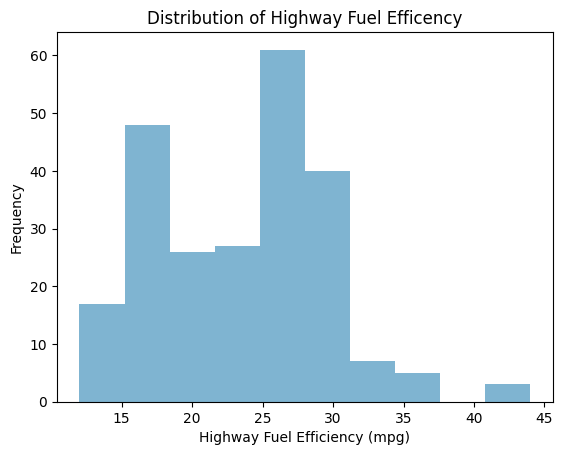

In [50]:
mpg.hwy.plot(
    kind="hist", # Specify what kind of plot you want
    alpha=0.5, # Make the bars slightly transparent (optional)
    title="Distribution of Highway Fuel Efficency", # Give your plot a title
    xlabel="Highway Fuel Efficiency (mpg)" # Label the x-axis
)
plt.show() # This makes sure the plot displays properly

Using `.pivot()` (see above), you can split up the distributions by category.

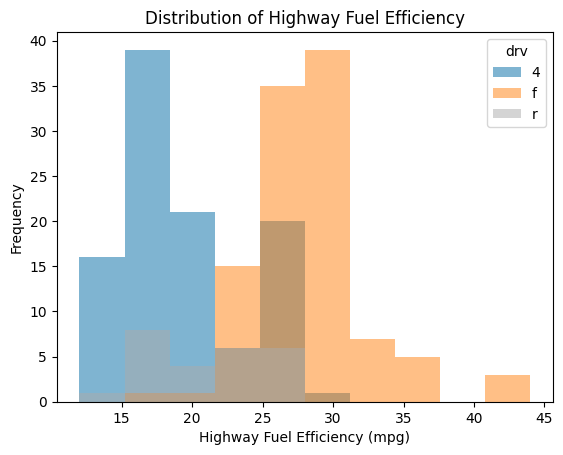

In [51]:
mpg.pivot(columns="drv", values="hwy").plot(
    kind="hist",
    alpha=0.5,
    title="Distribution of Highway Fuel Efficiency",
    xlabel="Highway Fuel Efficiency (mpg)"
)
plt.show()

If this is hard to read, you can also split the distributions into separate subplots. This process is sometimes called faceting.

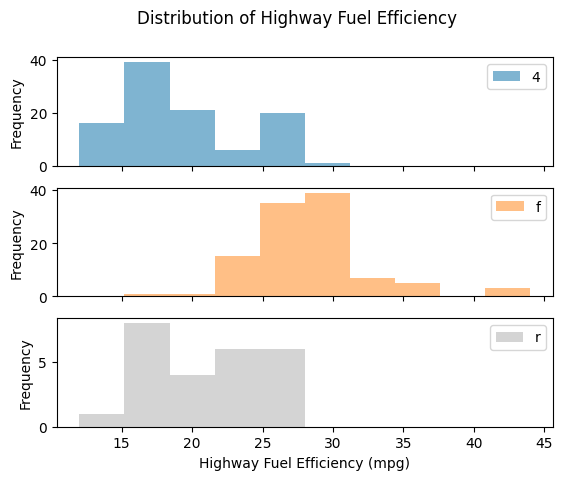

In [52]:
mpg.pivot(columns="drv", values="hwy").plot(
    kind="hist",
    alpha=0.5,
    title="Distribution of Highway Fuel Efficiency",
    xlabel="Highway Fuel Efficiency (mpg)",
    subplots=True
)
plt.show()

If you use a different `kind` of plot, you can show the distribution as a density plot instead of a histogram.

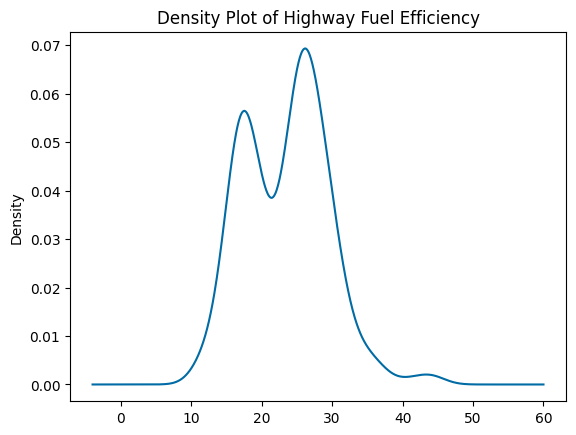

In [53]:
mpg.hwy.plot(
    kind="density",
    title="Density Plot of Highway Fuel Efficiency",
    xlabel="Highway Fuel Efficiency (mpg)"
)
plt.show()

### Category Plots

Category plots let you compare groups according to categorical variables. You can create a box plot to compare medians and distributions among groups instead of using multiple histograms. This shows a different kind of distribution, split up by category.

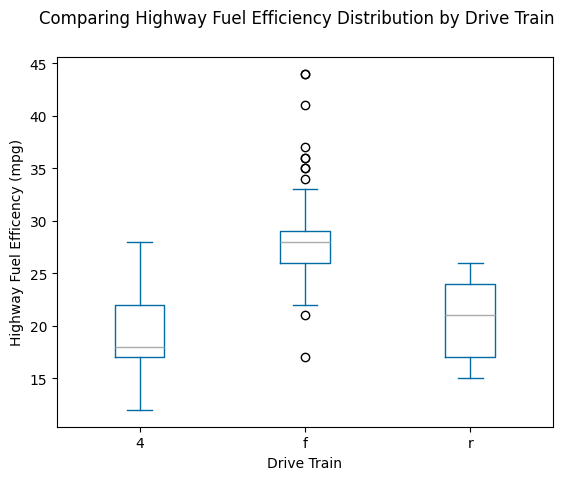

In [54]:
mpg.plot(
    kind="box",
    by="drv",
    column="hwy",
    title="Comparing Highway Fuel Efficiency Distribution by Drive Train",
    xlabel="Drive Train",
    ylabel="Highway Fuel Efficency (mpg)"
)
plt.title(None) # Remove unnecessary grouping title
plt.show()

Another standard category plot is the bar plot, which usually compares means of different groups. In Pandas, we create a bar plot based on a `.groupby()` object, where we have already calculated the means across different groups.

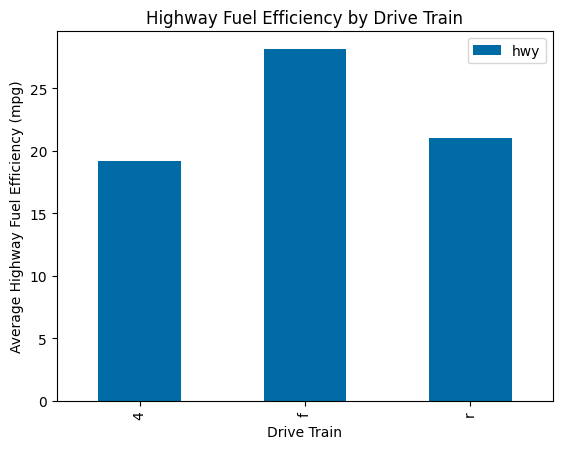

In [55]:
mpg.groupby("drv").mean(numeric_only=True).reset_index().plot(
    kind="bar",
    y="hwy", 
    x="drv",
    title="Highway Fuel Efficiency by Drive Train",
    xlabel="Drive Train",
    ylabel="Average Highway Fuel Efficiency (mpg)"
)
plt.show()

### Relationship Plots

To show a correlation or regression between two variables, use a simple scatterplot. Scatterplots take two numerical (quantitative) variables).

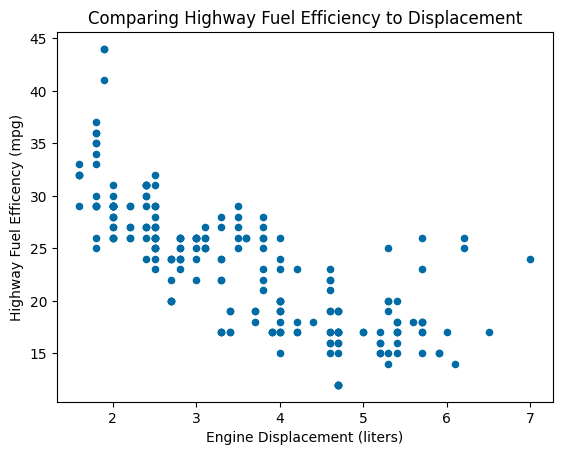

In [56]:
mpg.plot(
    kind="scatter",
    x="displ", 
    y="hwy",
    title="Comparing Highway Fuel Efficiency to Displacement",
    xlabel="Engine Displacement (liters)",
    ylabel="Highway Fuel Efficency (mpg)"
)
plt.show()

You can also create scatterplots with different colors for a categorical variable.

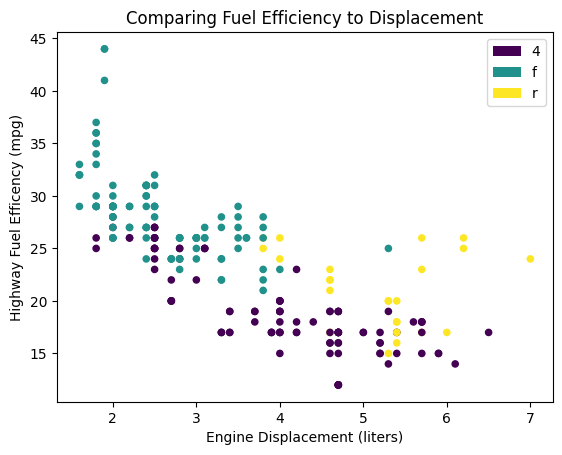

In [57]:
mpg.plot(
    kind="scatter",
    x="displ", 
    y="hwy", 
    c="drv",
    title="Comparing Fuel Efficiency to Displacement",
    xlabel="Engine Displacement (liters)",
    ylabel="Highway Fuel Efficency (mpg)"
)
plt.show()

Frequently you'll want to add a line of best fit to the graph in order to more clearly show a possible correlation. You can do that by adding a few extra lines of numpy code.

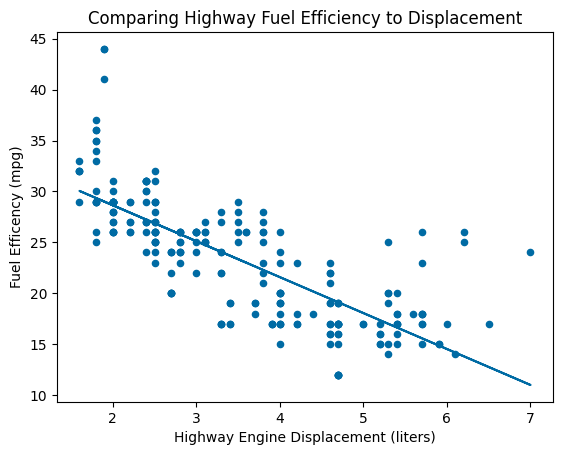

In [59]:
# You must drop null values first!
mpg = mpg.dropna(subset=["displ", "hwy"])
mpg.plot(
    kind="scatter",
    x="displ", 
    y="hwy",
    title="Comparing Highway Fuel Efficiency to Displacement",
    xlabel="Highway Engine Displacement (liters)",
    ylabel="Fuel Efficency (mpg)"
)
# The code below creates a line of best fit and adds it to your plot
m,b = np.polyfit(x=mpg["displ"], y=mpg["hwy"], deg=1)
plt.plot(mpg.displ, m * mpg.displ + b)
plt.show()

If your scatterplot is "overplotted," meaning that it has too many points on it to be readable, you can use a hexmap style plot to group the points into easier-to-read shaded areas.

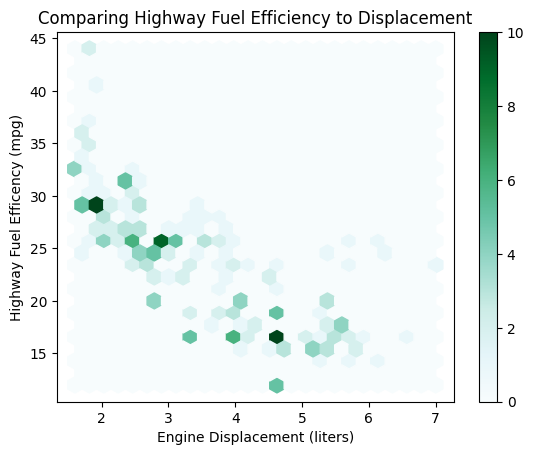

In [62]:
mpg.plot(
    kind="hexbin",
    x="displ", 
    y="hwy", 
    gridsize=25,
    title="Comparing Highway Fuel Efficiency to Displacement",
    xlabel="Engine Displacement (liters)",
    ylabel="Highway Fuel Efficency (mpg)"
)
plt.show()

Line plots are also a kind of relationship plot. Line plots are often used with time variables, and the mpg dataset only includes two years. To make this easier to see, we'll use Vega's similar `cars` dataset. Note that you must use a `.groupby()` summary table to average the fuel efficiency by year, like you did for the bar plot.

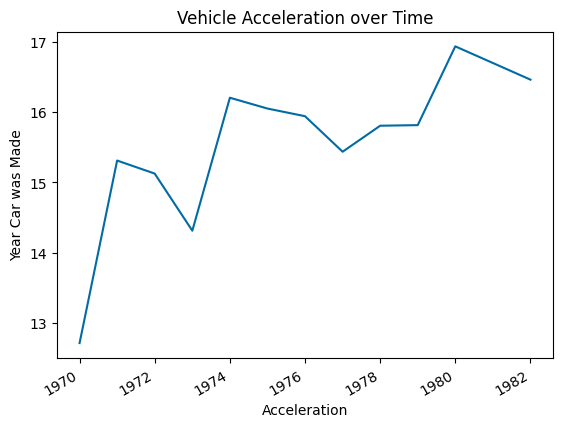

In [61]:
from vega_datasets import data
cars = data.cars()

cars.groupby("Year").mean(numeric_only=True).reset_index().plot(
    kind="line",
    x="Year", 
    y="Acceleration",
    title="Vehicle Acceleration over Time",
    ylabel="Year Car was Made",
    xlabel="Acceleration",
    legend=False
)
plt.show()

### Special Plot Types

There are additional special plot types we will use for specific purposes. For instance, sometimes it's necessary to show many different scatterplots at once time, using a pairplot. Pandas has a [special plotting module](https://pandas.pydata.org/docs/user_guide/visualization.html#plotting-tools) to import for some of these special plots.

In [63]:
from pandas.plotting import scatter_matrix

Typically you would add the above line to the very top of your code. Once that's important, you can create the pairplot.

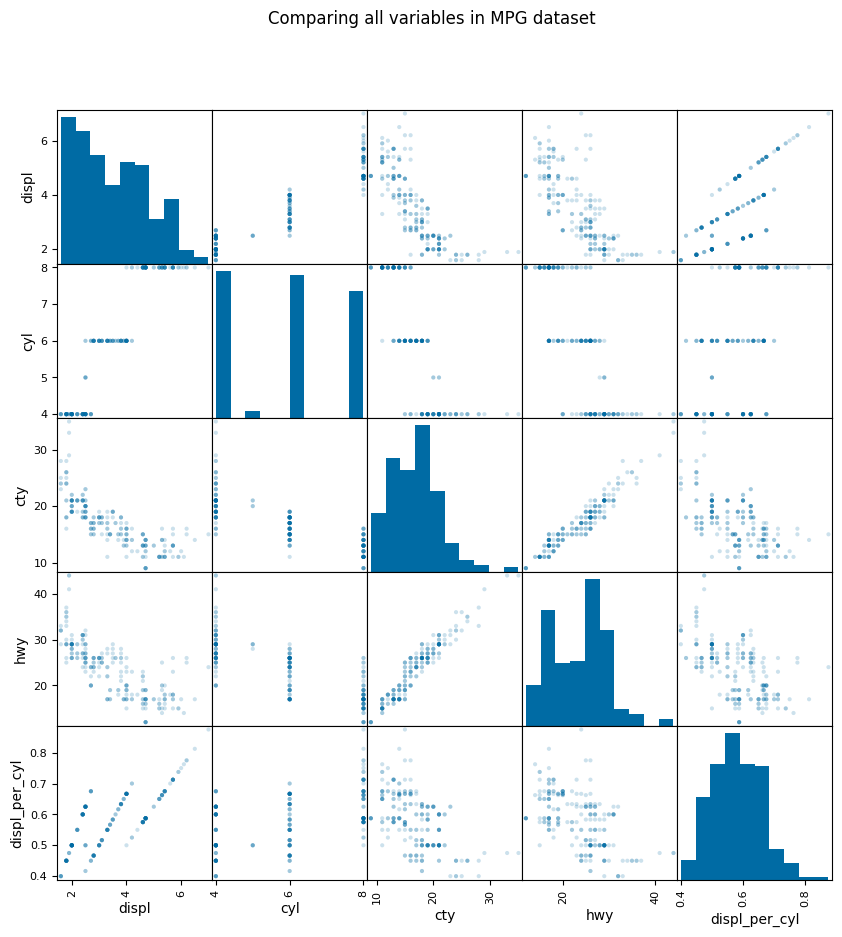

In [64]:
scatter_matrix(
    mpg, 
    alpha=0.2, 
    figsize=(10, 10), 
    diagonal="hist"
)
plt.suptitle("Comparing all variables in MPG dataset")
plt.show()

It can also be useful to add styling directly to a table. You can think of this as similar to adding colors to a spreadsheet. This is particularly useful to show a heatmap of correlation coefficients. There's a [separate section of the Pandas documentation](https://pandas.pydata.org/docs/user_guide/style.html) that covers this kind of visualization.

In [66]:
# First create a correlation matrix
corr = mpg.corr(numeric_only=True)
# Then add the colors
corr.style.background_gradient(cmap ='coolwarm')

,displ,cyl,cty,hwy,displ_per_cyl
displ,1.000000,0.930227,-0.798524,-0.766020,0.757498
cyl,0.930227,1.000000,-0.805771,-0.761912,0.482337
cty,-0.798524,-0.805771,1.000000,0.955916,-0.564699
hwy,-0.766020,-0.761912,0.955916,1.000000,-0.566210
displ_per_cyl,0.757498,0.482337,-0.564699,-0.566210,1.000000
